In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
dried_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [7506,9893,5840,6320,6853,7532,8307,8178,12574,9692,14167,24293,22414,31688,47053,79059,53721,72953,67901,70544,43320,61071,88997,95296,84417,85661,73679,252918],
'Price': [44.97,42.67,34.85,40.51,44.33,70.22,67.96,84.23,145.68,121.01,132.56,183.16,258.88,420.75,981.11,954.94,562.65,819.9,998,1010.16,725.58,871.74,1042.37,1323.45,981.5,1148.38,1472.98,3080.92]}
df5=pd.DataFrame(dried_fish)

Dataset has 28 records and 3 columns


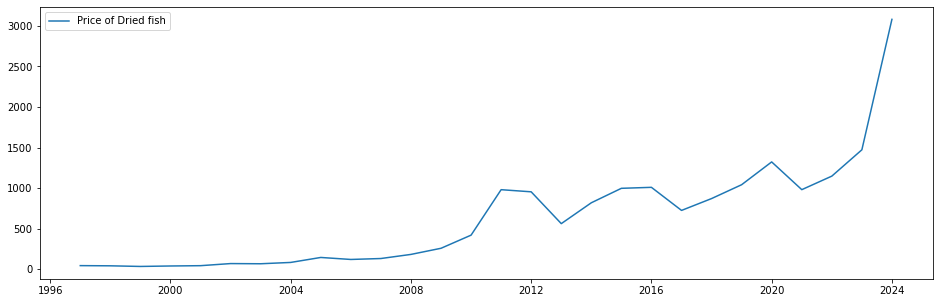

Results of Dickey-Fuller Test:
Test Statistic                  1.506329
p-value                         0.997547
#Lags Used                      0.000000
Number of Observations Used    27.000000
Critical Value (1%)            -3.699608
Critical Value (5%)            -2.976430
Critical Value (10%)           -2.627601
dtype: float64


In [3]:
# Check the dimensionality of the dataset
df5.shape
print("Dataset has {} records and {} columns".format(df5.shape[0], df5.shape[1]))
# Changing the YEAR data type and setting it as index
df5['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df5.index = df5['YEAR']
# Check the data type
del df5['YEAR']
# View the dataset
df5.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df5.index, df5['Price'], label = "Price of Dried fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df5test = adfuller(timeseries, autolag='AIC')
    df5output = pd.Series(df5test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df5test[4].items():
        df5output['Critical Value (%s)'%key] = value
    print (df5output)
# Call the function and run the test

adf_test(df5['Price'])


In [103]:
df5['Price_diff'] =df5['Price'].diff()
df5= df5.dropna()


In [104]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Price_diff'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                 -0.465769
p-value :                         0.898525
#lags used :                      3.000000
number of observations used :    23.000000
critical value (1%)              -3.752928
critical value (5%)              -2.998500
critical value (10%)             -2.638967
dtype: float64


In [105]:
df5['Price_diff_2'] =df5['Price_diff'].diff()
df5= df5.dropna()

In [106]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Price_diff_2'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                 -4.713763
p-value :                         0.000079
#lags used :                      2.000000
number of observations used :    23.000000
critical value (1%)              -3.752928
critical value (5%)              -2.998500
critical value (10%)             -2.638967
dtype: float64


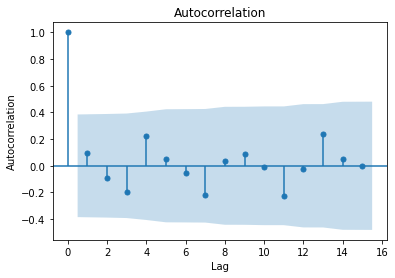

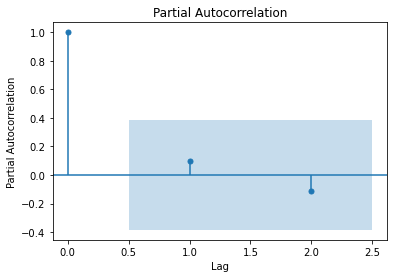

In [107]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df5['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=2)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [132]:
import pandas as pd
dried_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [7506,9893,5840,6320,6853,7532,8307,8178,12574,9692,14167,24293,22414,31688,47053,79059,53721,72953,67901,70544,43320,61071,88997,95296,84417,85661,73679,252918],
'Price': [44.97,42.67,34.85,40.51,44.33,70.22,67.96,84.23,145.68,121.01,132.56,183.16,258.88,420.75,981.11,954.94,562.65,819.9,998,1010.16,725.58,871.74,1042.37,1323.45,981.5,1148.38,1472.98,3080.92]}
df5=pd.DataFrame(dried_fish)

In [133]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                  1.430422
p-value :                         0.997248
#lags used :                      9.000000
number of observations used :    18.000000
critical value (1%)              -3.859073
critical value (5%)              -3.042046
critical value (10%)             -2.660906
dtype: float64


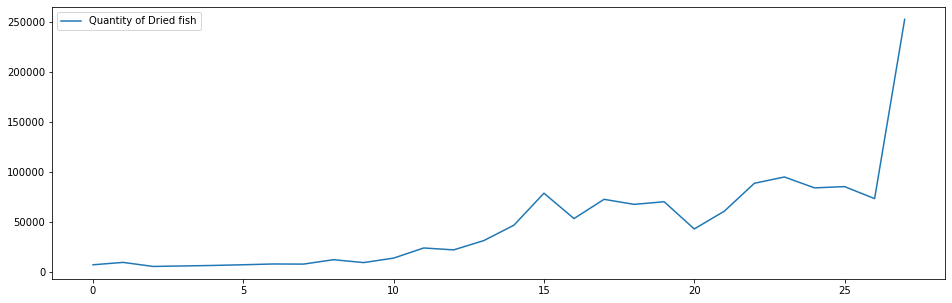

In [118]:
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df5.index, df5['Quantity'], label = "Quantity of Dried fish")
plt.legend(loc='best')
plt.show()

In [134]:
df5['Quantity_diff']=df5['Quantity'].diff()
df5=df5.dropna()


In [135]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity_diff'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                 -1.291272
p-value :                         0.633156
#lags used :                      9.000000
number of observations used :    17.000000
critical value (1%)              -3.889266
critical value (5%)              -3.054358
critical value (10%)             -2.666984
dtype: float64


In [136]:
df5['Quantity_diff_2']=df5['Quantity_diff'].diff(3)
df5=df5.dropna()

In [137]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity_diff_2'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                 -1.476010
p-value :                         0.545344
#lags used :                      8.000000
number of observations used :    15.000000
critical value (1%)              -3.964443
critical value (5%)              -3.084908
critical value (10%)             -2.681814
dtype: float64


In [138]:
df5['Quantity_diff_3']=df5['Quantity_diff_2'].diff(3)
df5=df5.dropna()
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity_diff_3'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                 -1.976659
p-value :                         0.296900
#lags used :                      8.000000
number of observations used :    12.000000
critical value (1%)              -4.137829
critical value (5%)              -3.154972
critical value (10%)             -2.714477
dtype: float64


In [139]:
df5['Quantity_diff_4']=df5['Quantity_diff_3'].diff(3)
df5=df5.dropna()
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity_diff_4'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                  1.191073
p-value :                         0.995924
#lags used :                      7.000000
number of observations used :    10.000000
critical value (1%)              -4.331573
critical value (5%)              -3.232950
critical value (10%)             -2.748700
dtype: float64


In [140]:
df5['Quantity_diff_5']=df5['Quantity_diff_4'].diff(3)
df5=df5.dropna()
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df5test = adfuller(df5['Quantity_diff_5'],autolag='AIC')
df5output=pd.Series(df5test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df5test[4].items():
    df5output['critical value (%s)'%key]= value
print(df5output)

Results of Dickey-fuller test:
Test Statistic :                -3.643046
p-value :                        0.004989
#lags used :                     5.000000
number of observations used :    9.000000
critical value (1%)             -4.473135
critical value (5%)             -3.289881
critical value (10%)            -2.772382
dtype: float64


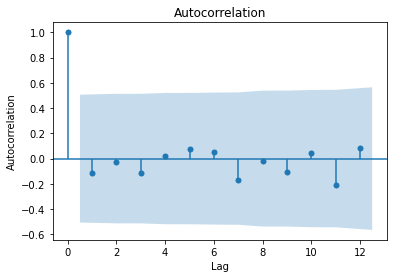

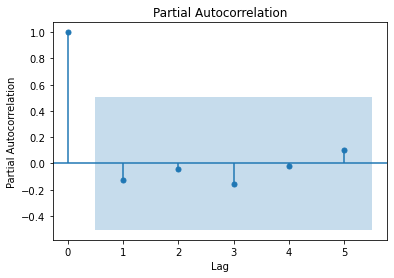

In [142]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df5['Quantity_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=5)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [75]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df5['Quantity'])

# Fit the OLS model
model = sm.OLS(df5['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = 348.1828938309116 + 0.008519582248358585 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     11.82
Date:                Sun, 16 Jul 2023   Prob (F-statistic):            0.00636
Time:                        22:46:13   Log-Likelihood:                -75.107
No. Observations:                  12   AIC:                             154.2
Df Residuals:                      10   BIC:                             155.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [144]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df5[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
print(model)
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                Quantity      Price
const        9352.290433  57.851012
L1.Quantity    -1.715310  -0.017802
L1.Price      173.393279   2.084234
L2.Quantity     0.370303   0.010377
L2.Price        4.782110  -0.414915


Estimated Coefficients:
[[[-1.71531027e+00  1.73393279e+02]
  [-1.78019040e-02  2.08423421e+00]]

 [[ 3.70302751e-01  4.78210973e+00]
  [ 1.03773875e-02 -4.14915120e-01]]]
Forecasted Values:
[[144057.75668105   2130.221758  ]
 [240004.20488384   3279.53751122]
 [229852.31289535   3231.72539862]
 [280001.0462786    3831.60175555]
 [294007.02101825   4103.62948989]
 [338589.09798078   4692.78104985]
 [370759.24167755   5159.54203515]
 [415836.93463287   5777.88903463]
 [459876.71361888   6404.37609534]
 [512612.87095243   7137.35710631]]


In [1]:
import pandas as pd
dried_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [7506,9893,5840,6320,6853,7532,8307,8178,12574,9692,14167,24293,22414,31688,47053,79059,53721,72953,67901,70544,43320,61071,88997,95296,84417,85661,73679,252918],
'Price': [44.97,42.67,34.85,40.51,44.33,70.22,67.96,84.23,145.68,121.01,132.56,183.16,258.88,420.75,981.11,954.94,562.65,819.9,998,1010.16,725.58,871.74,1042.37,1323.45,981.5,1148.38,1472.98,3080.92]}
df5=pd.DataFrame(dried_fish)

In [5]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df5[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df5['Price'])
is_quantity_stationary = are_series_stationary(df5['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


The variables price and quantity are cointegrated.


In [6]:
num_cointegrated_vectors

1

In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df5[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[156799.97510893   2132.15862019]
 [191773.58939752   2531.6834675 ]
 [181486.13730432   2426.2818156 ]
 [187500.82147223   2474.98997417]
 [183909.88286219   2438.82253189]
 [184987.64060122   2452.51131179]
 [184760.21323958   2450.3764435 ]
 [184976.69334887   2451.86558866]
 [184834.27725402   2450.36483476]
 [184863.28605213   2450.82023588]]


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  warnings.warn('No frequency information was'


(array([[156799.97510893,   2132.15862019],
        [191773.58939752,   2531.6834675 ],
        [181486.13730432,   2426.2818156 ],
        [187500.82147223,   2474.98997417],
        [183909.88286219,   2438.82253189],
        [184987.64060122,   2452.51131179],
        [184760.21323958,   2450.3764435 ],
        [184976.69334887,   2451.86558866],
        [184834.27725402,   2450.36483476],
        [184863.28605213,   2450.82023588]]),
 array([[105315.40569786,   1504.6298033 ],
        [118914.55326639,   1607.11434797],
        [ 93469.28603897,   1306.64754785],
        [ 89766.86203619,   1223.54111747],
        [ 76868.73305317,   1058.62990702],
        [ 69206.93845543,    952.55579777],
        [ 60770.16297827,    839.67691373],
        [ 53397.10512974,    738.74726033],
        [ 46074.43371164,    640.34645554],
        [ 39264.85317293,    548.68429121]]),
 array([[208284.54452001,   2759.68743707],
        [264632.62552865,   3456.25258703],
        [269502.98856967,   

In [7]:
coint_vectors

array([[ 1.49308373e-04, -2.32628930e-05],
       [-1.12622944e-02,  2.23032051e-04]])

In [7]:
vecm_res = model.fit()
vecm_res.gamma.round(4)
vecm_res.summary()
print(model)
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.4623,0.658,-0.703,0.482,-1.751,0.827
L1.Price,19.0477,50.231,0.379,0.705,-79.403,117.498
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.0102,0.008,-1.270,0.204,-0.026,0.006
L1.Price,0.6431,0.612,1.050,0.294,-0.557,1.843
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-2.1384,0.769,-2.780,0.005,-3.646,-0.631
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0077,0.009,-0.820,0.412,-0.026,0.011
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[105315.406   1504.63 ]
 [118914.553   1607.114]
 [ 93469.286   1306.648]
 [ 89766.862   1223.541]
 [ 76868.733   1058.63 ]]

point forecasts:
[[156799.975   2132.159]
 [191773.589   2531.683]
 [181486.137   2426.282]
 [187500.821   2474.99 ]
 [183909.883   2438.823]]

upper bounds of confidence intervals:
[[208284.545   2759.687]
 [264632.626   3456.253]
 [269502.989   3545.916]
 [285234.781   3726.439]
 [290951.033   3819.015]]


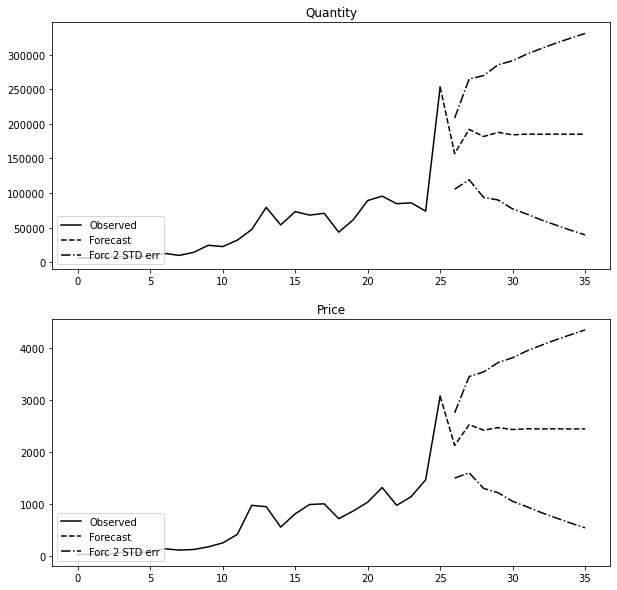

In [8]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
